In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score,normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples , davies_bouldin_score
from scipy.spatial.distance import cdist

In [40]:
data=load_breast_cancer()

In [41]:
x=data.data
y=data.target
df = pd.DataFrame(x, columns=data.feature_names)

In [42]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [43]:
sc=StandardScaler()
x=sc.fit_transform(x)

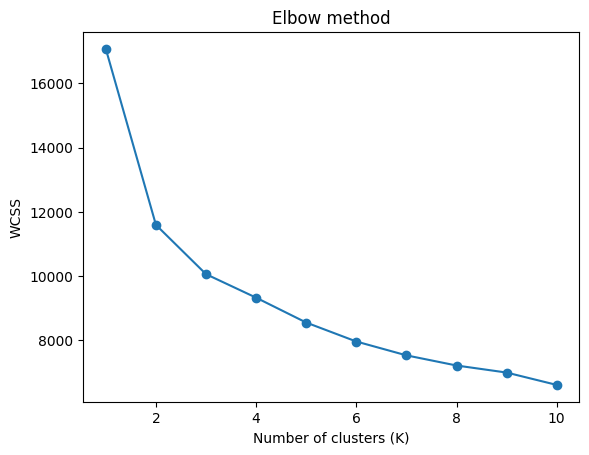

In [44]:
wcss=[]
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init=10)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [45]:
kmeans = KMeans(n_clusters=2, random_state=0)
clusters=kmeans.fit_predict(x)
df['Cluster']=clusters
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Cluster
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


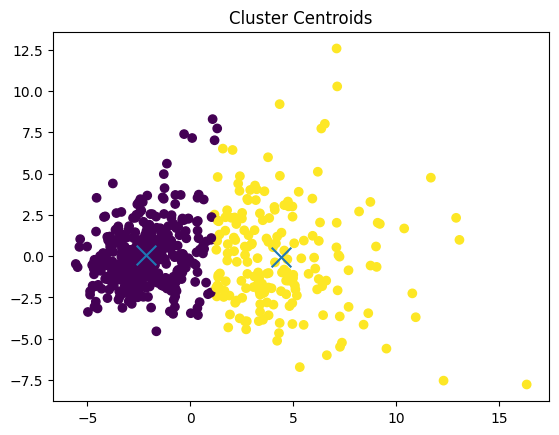

In [48]:
centroids = kmeans.cluster_centers_
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)
centroids_pca = pca.transform(centroids)

plt.figure()
plt.scatter(x_pca[:,0],x_pca[:,1],c=clusters)
plt.scatter(centroids_pca[:,0],centroids_pca[:,1],marker='x',s=200)
plt.title("Cluster Centroids")
plt.show()

wss: 6615.952708881649
[1.         0.47632977 0.32961828 0.25963397 0.18559643 0.12918981
 0.08798289 0.05778316 0.03678772 0.        ]


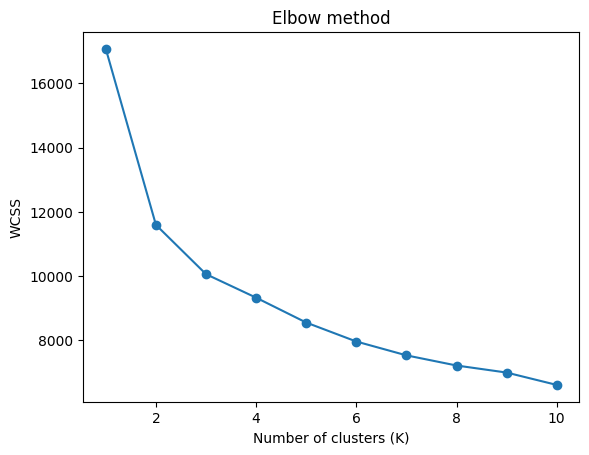

In [50]:
print('wss:', kmeans.inertia_)
wcss=[]
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init=10)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
wss_score=(wcss- np.min(wcss))/(np.max(wcss)-np.min(wcss))
print(wss_score)
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [61]:
sil=silhouette_score(x,clusters)
print("silhouette score:" , sil)
db=davies_bouldin_score(x,clusters)
print('Davies score: ', db)


silhouette score: 0.3447344346611054
Davies score:  1.3092887340398864


Silhouette Score: 0.3447344346611054


Text(0.5, 1.0, 'Silhouette Plot')

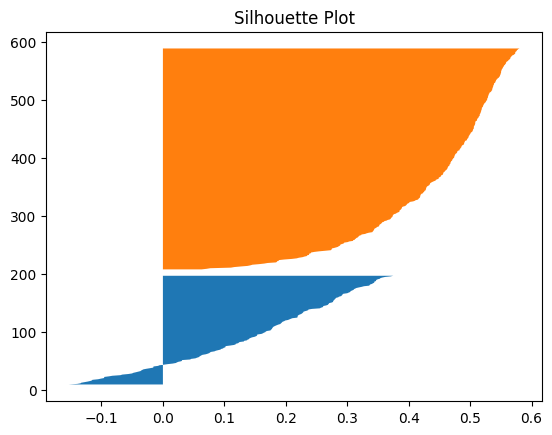

In [54]:
kmeans = KMeans(n_clusters=2,random_state=42)
labels = kmeans.fit_predict(x)
sil_avg = silhouette_score(x,labels)
print("Silhouette Score:",sil_avg)
sample_silhouette_values = silhouette_samples(x,labels)

plt.figure()
y_lower = 10
for i in range(2):
  ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
  ith_cluster_silhouette_values.sort()

  size_cluster_i = ith_cluster_silhouette_values.shape[0]
  y_upper = y_lower + size_cluster_i

  plt.fill_betweenx(np.arange(y_lower , y_upper),0,ith_cluster_silhouette_values)
  y_lower = y_upper + 10

plt.title("Silhouette Plot")

In [56]:
def dum_index(x,labels):
  clusters=np.unique(labels)
  intra=[]
  inter=[]
  for c in clusters:
    cluster_points=x[labels==c]
    intra.append(np.max(cdist(cluster_points, cluster_points)))

  for i in range(len(clusters)):
    for j in range(i+1, len(clusters)):
      cluster_i=x[labels==clusters[i]]
      cluster_j=x[labels==clusters[j]]
      inter.append(np.min(cdist(cluster_i, cluster_j)))
  return np.min(inter)/np.max(intra)
dum=dum_index(x, labels)
print('dum index: ', dum)


dum index:  0.06076298565537046


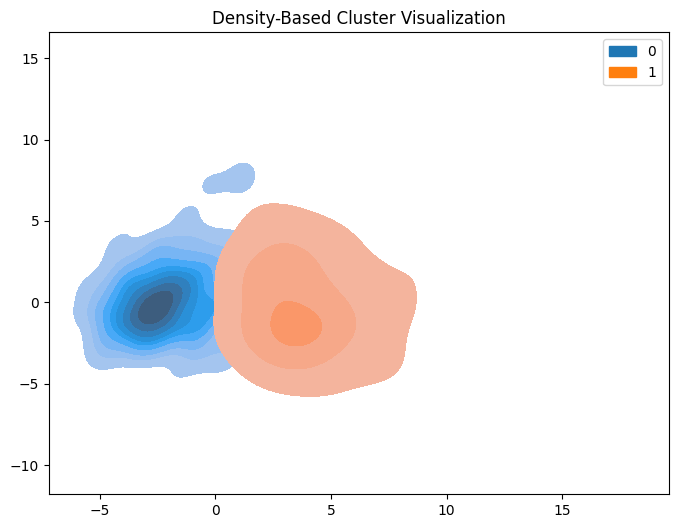

In [59]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.kdeplot(x=x_pca[:,0], y=x_pca[:,1], hue=clusters, fill=True)
plt.title("Density-Based Cluster Visualization")
plt.show()

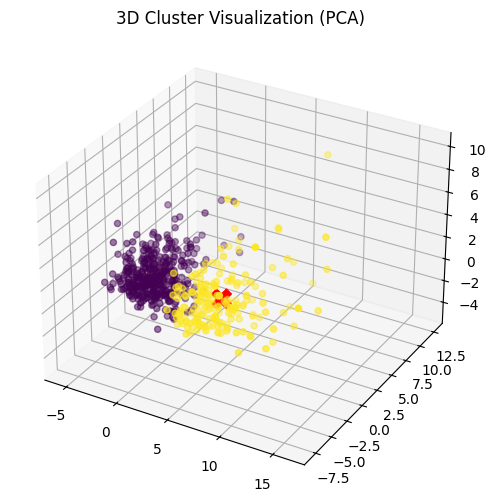

In [62]:
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(x)
centroids_3d = pca.transform(centroids)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_pca_3d[:,0],
    X_pca_3d[:,1],
    X_pca_3d[:,2],
    c=clusters,
    cmap='viridis',
    s=20
)
ax.scatter(
    centroids_3d[:,0],
    centroids_3d[:,1],
    centroids_3d[:,2],
    marker='X',
    s=200,
    c='red'
)

ax.set_title("3D Cluster Visualization (PCA)")


plt.show()

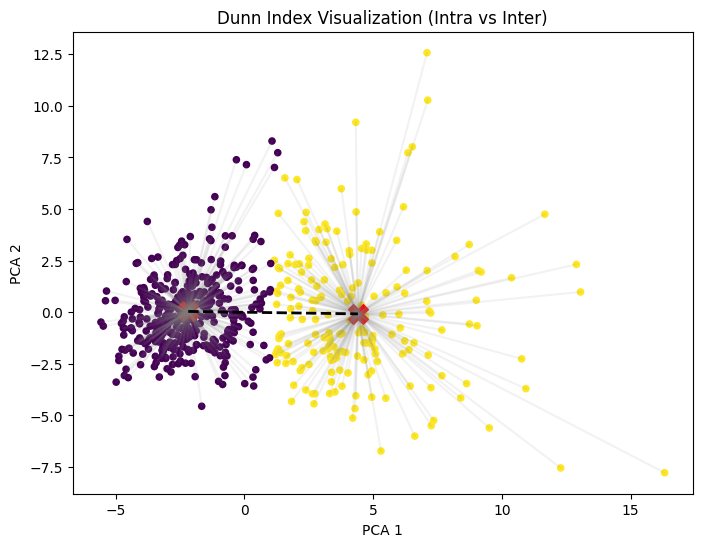

In [64]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x)


centroids_pca = pca.transform(centroids)

plt.figure(figsize=(8,6))


plt.scatter(x_pca[:,0], x_pca[:,1], c=clusters, cmap='viridis', s=20)


plt.scatter(centroids_pca[:,0], centroids_pca[:,1],
            marker='X', s=200, c='red')


for i in range(len(x_pca)):
    plt.plot([x_pca[i,0], centroids_pca[clusters[i],0]],
             [x_pca[i,1], centroids_pca[clusters[i],1]],
             'gray', alpha=0.1)


for i in range(len(centroids_pca)):
    for j in range(i+1, len(centroids_pca)):
        plt.plot([centroids_pca[i,0], centroids_pca[j,0]],
                 [centroids_pca[i,1], centroids_pca[j,1]],
                 'black', linestyle='--', linewidth=2)

plt.title("Dunn Index Visualization (Intra vs Inter)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


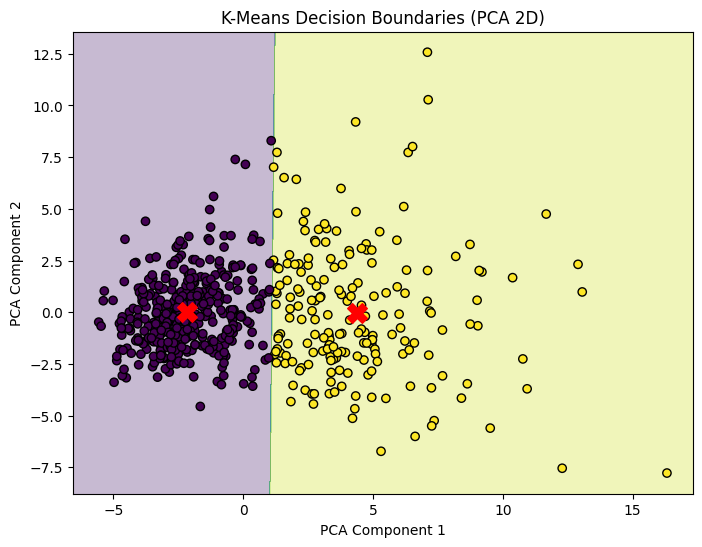

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Step 1: Reduce data to 2D (for visualization)
pca = PCA(n_components=2)
x_2d = pca.fit_transform(x)

# Step 2: Train KMeans on 2D data
kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(x_2d)

# Step 3: Create mesh grid
h = 0.02
x_min, x_max = x_2d[:, 0].min() - 1, x_2d[:, 0].max() + 1
y_min, y_max = x_2d[:, 1].min() - 1, x_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# Step 4: Predict cluster for each grid point
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Step 5: Plot decision boundary
plt.figure(figsize=(8,6))

# Background regions (decision boundary)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Data points
plt.scatter(x_2d[:, 0], x_2d[:, 1], c=labels, cmap='viridis', edgecolor='k')

# Centroids
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')

plt.title("K-Means Decision Boundaries (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()